# Human Activity Recognition with Wifi

In [22]:
import numpy as np
import numpy.random as rnd
import torch
import matplotlib.pyplot as plt

from models.DopplerDataset import * 
from torch.utils.data import DataLoader
from os import listdir, makedirs, path
from shutil import copy

%load_ext autoreload
%autoreload 2


###############  GLOBAL VARIABLES  #################

PERFORM_DATASET_SEPARATION = True
DATASET_PATH               = "./doppler_traces"
TEST_DATASET_FRACTION      = 0.1
DOPPLER_TRACE_SIZE         = 340

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Separating training dataset and test dataset

In [ ]:
'''
    We split each Doppler trace in DATASET_PATH into several Doppler sub-traces of size DOPPLER_TRACE_SIZE,
    then we randomly split each collection of sub-traces into a train/test dataset folder.
'''

train_dataset = DATASET_PATH + "_train"
test_dataset  = DATASET_PATH + "_test"

if PERFORM_DATASET_SEPARATION and (train_dataset not in listdir()) and (test_dataset not in listdir()):
    subdir_list = sorted([name for name in listdir(DATASET_PATH) if path.isdir(DATASET_PATH+'/'+name)])

    # Counting number of images in DATASET_PATH
    traces_number = 0
    for subdir in subdir_list:
        traces_number += len(listdir(DATASET_PATH+'/'+subdir))
    print(f"Dataset {DATASET_PATH} contains {traces_number} traces.\nProceding to create training dataset with {int((1-TEST_DATASET_FRACTION)*traces_number)} traces and test dataset with {int(TEST_DATASET_FRACTION*traces_number)} traces...\n")

    # Creating train and test datasets
    makedirs(train_dataset, exist_ok=True)
    makedirs(test_dataset, exist_ok=True)

    # Creating a index array to split traces into different datasets
    index = np.arange(0, traces_number)
    rnd.shuffle(index)
    test_index  = index[:int(traces_number*TEST_DATASET_FRACTION)]

    # Splitting a trace in many sub-traces and randomly assigning them to train/test dataset
    idx = 0
    for subdir in subdir_list:
        for trace_name in sorted(listdir(DATASET_PATH+'/'+subdir)):
            trace_path = DATASET_PATH+'/'+subdir+'/'+trace_name
            full_trace = np.load(trace_path, allow_pickle=True)
            N_images = full_trace.shape[0]//DOPPLER_TRACE_SIZE

            for i in range(N_images):
                # Name of sub-trace is the one the original full trace + an index to distinguish
                if idx in test_index:
                    np.save(test_dataset+'/'+trace_name[:-4]+f"-{i}", full_trace[i*DOPPLER_TRACE_SIZE:(i+1)*DOPPLER_TRACE_SIZE, :], allow_pickle=True)
                else:
                    np.save(train_dataset+'/'+trace_name[:-4]+f"-{i}", full_trace[i*DOPPLER_TRACE_SIZE:(i+1)*DOPPLER_TRACE_SIZE, :], allow_pickle=True)
            
            # All sub-traces of the same file are assigned to the same dataset
            idx += 1

    print("Train and test datasets created successfully!")
else:
    print("Datasets are already splitted!")

Dataset ./doppler_traces contains 400 traces.
Proceding to create training dataset with 360 traces and test dataset with 40 traces...

Train and test datasets created successfully!


## Loading Dataset

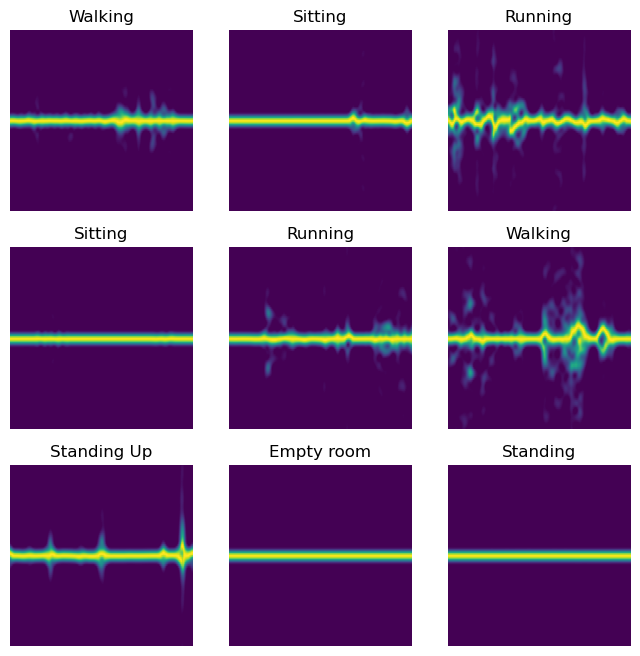

In [42]:
train_dataset = DopplerDataset("doppler_traces_train")
train_dataloader = DataLoader(train_dataset, batch_size=30, shuffle=True)

test_dataset  = DopplerDataset("doppler_traces_test")
test_dataloader = DataLoader(test_dataset, batch_size=10, shuffle=True)

labels_map = {
    "S": "Standing",
    "W": "Walking",
    "R": "Running",
    "C": "Standing Up",
    "E": "Empty room",
    "L": "Sitting",
    "H": "Moving arm",
    "J": "Jumping"
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols*rows + 1):
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, label = train_dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img, aspect='auto')
plt.show()